In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/anubhavpathak0411/placement/placement.csv


In [2]:
df=pd.read_csv("/kaggle/input/datasets/anubhavpathak0411/placement/placement.csv")
df

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0
...,...,...,...,...
95,95,4.3,200.0,0
96,96,4.4,42.0,0
97,97,6.7,182.0,1
98,98,6.3,103.0,1


In [3]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [4]:
#steps
# Steps
#0. Preprocess + EDA + Feature Selection-exploratory data analysis
#1. Extract input and output cols
#2. Scale the values
#3. Train test split
#4. Train the model
#5. Evaluate the model/model selection
#6. Deploy the model

In [5]:
df=df.iloc[:,1:]
df

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


In [6]:
import matplotlib.pyplot as plt


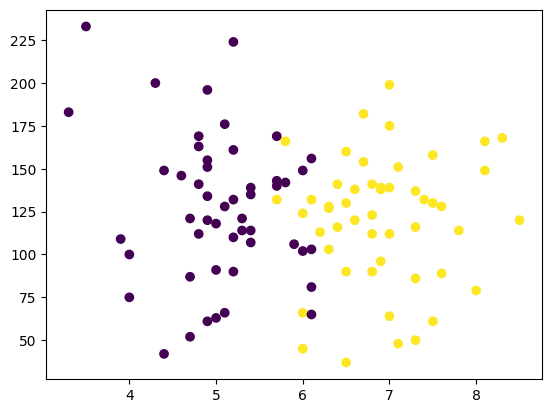

In [7]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [8]:
x=df.iloc[:,0:2]
y=df.iloc[:,-1]
x


,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [9]:
y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1)
x_train

,cgpa,iq
6,5.7,143.0
79,6.5,90.0
0,6.8,123.0
69,8.5,120.0
24,4.7,121.0
...,...,...
11,6.9,138.0
66,6.9,96.0
84,5.7,169.0
57,6.5,130.0


In [12]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train = scaler.fit_transform(x_train)
x_train

array([[-2.59593669e-01,  4.58072306e-01],
       [ 4.30101687e-01, -8.71006100e-01],
       [ 6.88737445e-01, -4.34667152e-02],
       [ 2.15434008e+00, -1.18697568e-01],
       [-1.12171286e+00, -9.36206173e-02],
       [-5.18229427e-01,  3.57764502e-01],
       [ 3.43889768e-01,  4.07918404e-01],
       [-2.59593669e-01,  3.82841453e-01],
       [ 3.43889768e-01, -2.19005373e-01],
       [ 1.29222088e+00,  1.32071942e-01],
       [ 2.57677848e-01,  8.19180401e-02],
       [ 5.16313606e-01, -1.18697568e-01],
       [-1.72519630e+00, -6.20236589e-01],
       [ 1.55085664e+00, -2.69159275e-01],
       [-1.73381749e-01,  1.03484218e+00],
       [ 8.61161284e-01,  3.57764502e-01],
       [-9.57910216e-04, -1.99946890e+00],
       [-6.90653266e-01, -3.69467079e-01],
       [-6.90653266e-01,  2.48930534e+00],
       [-1.12171286e+00, -9.46236953e-01],
       [-2.32867973e+00,  1.46115035e+00],
       [-6.04441346e-01, -9.36206173e-02],
       [-9.49289024e-01,  1.78715071e+00],
       [-1.

In [13]:
x_train.shape

(90, 2)

In [14]:
x_test = scaler.transform(x_test)
x_test

array([[-1.72519630e+00, -1.24716037e+00],
       [ 8.61161284e-01,  1.26053474e+00],
       [ 1.11979704e+00, -9.71313904e-01],
       [ 8.52540092e-02, -1.49792988e+00],
       [-8.63077105e-01, -1.68851470e-01],
       [ 1.71465929e-01, -2.94236226e-01],
       [-9.57910216e-04, -5.70082687e-01],
       [-6.90653266e-01,  9.09457425e-01],
       [ 8.52540092e-02, -1.09669866e+00],
       [ 8.52540092e-02,  7.84072670e-01]])

In [15]:
from sklearn.linear_model import LogisticRegression

In [16]:
clf=LogisticRegression()


In [17]:
clf.fit(x_train,y_train)
clf.get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [18]:
y_pred = clf.predict(x_test)
y_pred

array([0, 1, 1, 1, 0, 1, 1, 0, 1, 1])

In [19]:
y_test

68    0
52    1
90    1
56    0
67    0
99    1
62    0
47    0
78    0
8     0
Name: placement, dtype: int64

In [20]:
from sklearn.metrics import accuracy_score

In [21]:
accuracy_score(y_pred,y_test)

0.6

In [22]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

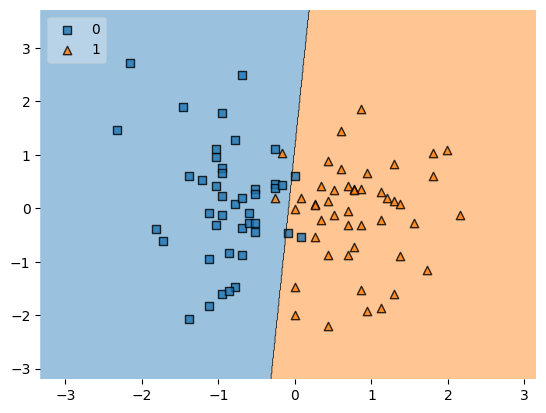

In [23]:
plot_decision_regions(x_train, y_train.values, clf=clf, legend=2)

In [24]:
import pickle

In [25]:
pickle.dump((clf),open('model.pkl','wb'))